## Cosmology: Background and Perturbations for binned DE

* change expansion: $$ \frac{H^2(z)}{H_0^2} = \Omega_{\rm m} (1+z)^3 + (1-\Omega_{\rm m}) f_{\rm DE}(z)$$ with $$f_{\rm DE}(z) = \left( \frac{1+z}{1+z_j-\Delta z_j/2} \right)^{3(1+w_j)} \Pi^{j-1}_{i=1} \left( \frac{1+z_i+\Delta z_i/2}{1+z_i-\Delta z_i/2}\right)^{3(1+w_i)}$$ or $$f_{\rm DE}(z) = \int_0^z dz' \frac{1+w(z')}{1+z'}$$ 
* change distances: $r_{\rm com}(z)=\int_0^{z} \frac{c \mathrm{d}z'}{H(z')}$
* change linear growth: JaxMGrowth

In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [3]:
import time

In [4]:
from cloelib.cosmology.binned_wz_cosmology import DEBackground, DELinearPerturbations, DENonlinearPerturbations


Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


# Cosmology: Background 

## 3 bins + high-redshift bin (+ $w_0$ for desi-binning)

In [5]:
w0 = -0.75
wa = -0.86
background_lcdm = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            gamma_MG = 0.545,
                            N_mnu=1)
background_cpl = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=w0, 
                            wa=wa, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            gamma_MG = 0.545,
                            N_mnu=1)

In [41]:
zs = np.linspace(1e-4, 3, 100)
zfinal = 1000.
zmax = 2.1
zmin_desi = 0.1
zmin = 0.
z_last_bin = 2.8
number_of_bins = 4

    

zbin_edges = np.array([zmin+(zmax-zmin)/number_of_bins*i for i in range(number_of_bins+1)]+[zfinal])
zbin_amp_z = [0.5*(zbin_edges[i] + zbin_edges[i+1]) for i in range(number_of_bins)]+[z_last_bin]
zbin_centers = 0.5*(zbin_edges[1:] + zbin_edges[:-1])
zbin_widths = np.diff(np.array(zbin_edges))
w_i_amp_cpl = [w0+wa*(zbin_amp_z[i]/(1.+zbin_amp_z[i])) for i in range(len(zbin_amp_z))]
w_i_amp_cpl_centers = np.array([w0+wa*(zbin_centers[i]/(1.+zbin_centers[i])) for i in range(len(zbin_centers))])
n_bin = len(zbin_amp_z)
print('for step-function (with and without smoothing:')
print('w_i: ', w_i_amp_cpl)
print('w_i_centers: ', w_i_amp_cpl_centers)
print('z-bin edges: ', zbin_edges)
print('z_i: ', zbin_amp_z)
print('z-bin widths: ', zbin_widths)
print('Nbin: ', n_bin, len(w_i_amp_cpl))

zbin_edges_desi = [zmin_desi+(zmax-zmin_desi)/number_of_bins*i for i in range(number_of_bins+1)]+[zfinal]
zbin_amp_z_desi = [0.5*(zbin_edges_desi[i] + zbin_edges_desi[i+1]) for i in range(number_of_bins)]+[z_last_bin]
zbin_widths_desi = np.diff(np.array(zbin_edges_desi))
w_i_amp_cpl_desi = [w0]+[w0+wa*(zbin_amp_z_desi[i]/(1.+zbin_amp_z_desi[i])) for i in range(len(zbin_amp_z_desi))]
n_bin_desi = len(zbin_amp_z_desi)

print('for desi-function:')
print('w_i: ', w_i_amp_cpl_desi)
print('z-bin edges: ', zbin_edges_desi)
print('z_i: ', zbin_amp_z_desi)
print('z-bin widths: ', zbin_widths_desi)
print('Nbin: ', n_bin_desi, len(w_i_amp_cpl_desi))

for step-function (with and without smoothing:
w_i:  [np.float64(-0.9288118811881189), np.float64(-1.128881118881119), np.float64(-1.238108108108108), np.float64(-1.3069162995594712), -1.3836842105263156]
w_i_centers:  [-0.92881188 -1.12888112 -1.23810811 -1.3069163  -1.60828702]
z-bin edges:  [0.000e+00 5.250e-01 1.050e+00 1.575e+00 2.100e+00 1.000e+03]
z_i:  [np.float64(0.2625), np.float64(0.7875000000000001), np.float64(1.3125), np.float64(1.8375000000000001), 2.8]
z-bin widths:  [5.250e-01 5.250e-01 5.250e-01 5.250e-01 9.979e+02]
Nbin:  5 5
for desi-function:
w_i:  [-0.75, -0.9729629629629629, -1.145135135135135, -1.2440425531914894, -1.3082456140350878, -1.3836842105263156]
z-bin edges:  [0.1, 0.6, 1.1, 1.6, 2.1, 1000.0]
z_i:  [0.35, 0.8500000000000001, 1.35, 1.85, 2.8]
z-bin widths:  [5.000e-01 5.000e-01 5.000e-01 5.000e-01 9.979e+02]
Nbin:  5 6


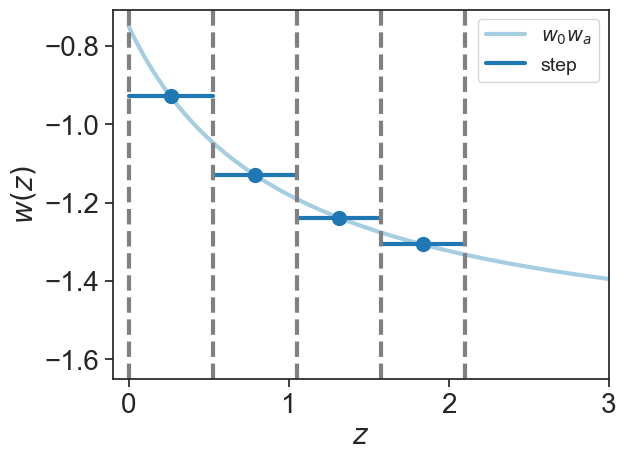

In [42]:
fig, ax = plt.subplots()
#ax.plot(zs, np.array(w_z), label='DESI-like binning')
ax.errorbar(zbin_centers, w_i_amp_cpl_centers,   marker='o',  markersize=10, linestyle='',color='C1')
ax.plot(zs, w0+wa*(zs/(1.+zs)), label='$w_0w_a$', color='C0')
for i in range(4):
    z_arr = np.linspace(zbin_edges[i], zbin_edges[i+1], 10)
    ax.plot(z_arr, w_i_amp_cpl_centers[i]*np.ones(10), color='C1', label='step' if i==0 else '')
    
for i in range(len(zbin_edges)):
    ax.axvline(zbin_edges[i], ls='--', color='grey')
ax.set_xlabel('$z$')
ax.set_ylabel('$w(z)$')
ax.set_xlim(-0.1, 3)
ax.legend()
plt.show()

In [43]:
# The arguments of the Background functions follow the cosmology.API
background_de = DEBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            zbin_edges = zbin_edges,
                            #zbin_widths = zbin_widths,
                            #zbin_centers = zbin_centers,
                            w_i = w_i_amp_cpl_centers
                            )


In [44]:
zs0 = np.array([0.])
zs0 = 0.
print(background_cpl.Omega_m(zs0))
print(background_de.Omega_m(zs0))


0.32084357042900397
0.3208416406233968


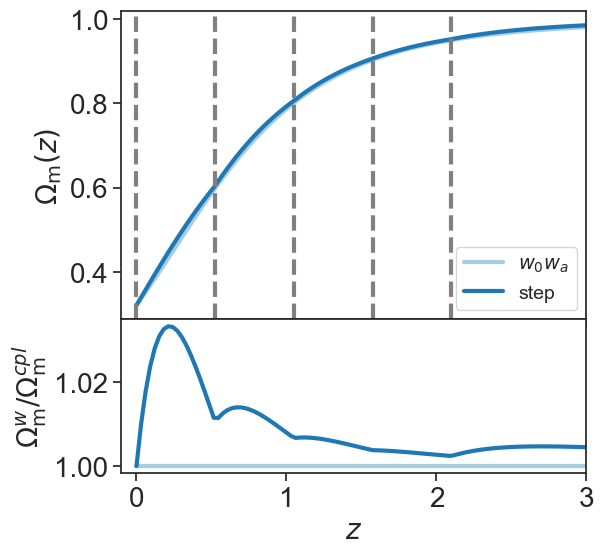

In [45]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.Omega_m(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de.Omega_m(zs), label='step', color='C1')


ax2.plot(zs, background_cpl.Omega_m(zs)/background_cpl.Omega_m(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de.Omega_m(zs)/background_cpl.Omega_m(zs), label='step', color='C1')


for i in range(len(zbin_edges)):
    ax1.axvline(zbin_edges[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$\\Omega_{\\rm m}(z)$')
ax2.set_ylabel('$\\Omega^{w}_{\\rm m}/\\Omega^{cpl}_{\\rm m}$')
ax2.set_xlim(-0.1, 3)
ax1.legend()
plt.show()

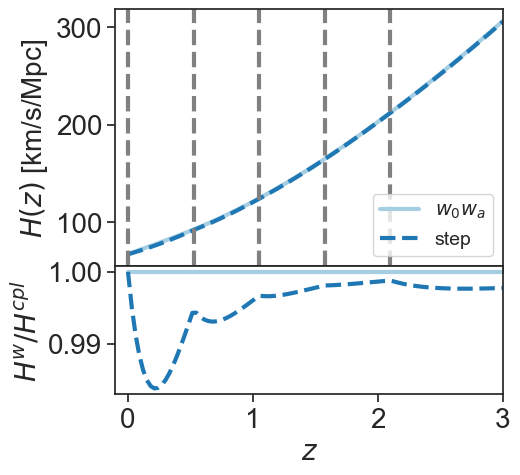

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de.hubble_parameter(zs), label='step', color='C1', linestyle='--')


ax2.plot(zs, background_cpl.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='step', color='C1', linestyle='--')


for i in range(len(zbin_edges)):
    ax1.axvline(zbin_edges[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$H(z)$ [km/s/Mpc]')
ax2.set_ylabel('$H^{w}/H^{cpl}$')
ax2.set_xlim(-0.1, 3)
ax1.legend()
plt.show()

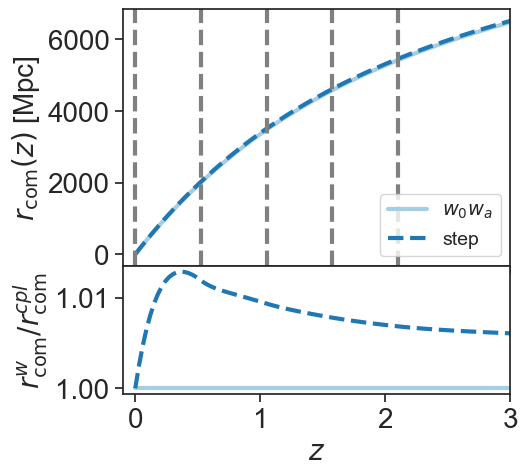

In [47]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de.comoving_distance(zs), label='step', color='C1', linestyle='--')


ax2.plot(zs, background_cpl.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='step', color='C1', linestyle='--')


for i in range(len(zbin_edges)):
    ax1.axvline(zbin_edges[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$r_{\\rm com}(z)$ [Mpc]')
ax2.set_ylabel('$r_{\\rm com}^{w}/r_{\\rm com}^{cpl}$')
ax2.set_xlim(-0.1, 3)
ax1.legend()
plt.show()

# Perturbations: linear and nonlinear

In [48]:
linear_perturbations_lcdm = HMemuLinearPerturbations(background_lcdm, zs)
linear_perturbations_cpl = HMemuLinearPerturbations(background_cpl, zs)

log10_t_agn = 7.75

nonlinear_perturbations_lcdm = HMemuNonLinearPerturbations(background_lcdm, linear_perturbations_lcdm, zs, log10TAGN=log10_t_agn)
nonlinear_perturbations_cpl = HMemuNonLinearPerturbations(background_cpl, linear_perturbations_cpl, zs, log10TAGN=log10_t_agn)

In [49]:
linear_perturbations_de = DELinearPerturbations(background_de, linear_perturbations_lcdm)
nonlinear_perturbations_de = DENonlinearPerturbations(background_de, linear_perturbations_de, zs, log10TAGN=log10_t_agn)

In [50]:
ks = np.logspace(np.log10(1e-3), np.log10(5), 100)
ps_lin_lcdm = linear_perturbations_lcdm.matter_power_spectrum(0, ks)
ps_lin_cpl = linear_perturbations_cpl.matter_power_spectrum(0, ks)
ps_lin_de = linear_perturbations_de.matter_power_spectrum(0, ks)
ps_nonlin_lcdm = nonlinear_perturbations_lcdm.matter_power_spectrum(0, ks)
start = time.time()
ps_nonlin_cpl = nonlinear_perturbations_cpl.matter_power_spectrum(0, ks)
finish = time.time()
print(finish-start)
start = time.time()
ps_nonlin_de = nonlinear_perturbations_de.matter_power_spectrum(0, ks)
finish = time.time()
print(finish-start)
print(ps_nonlin_cpl.shape, ps_nonlin_de.shape, ps_lin_cpl.shape, ps_lin_de.shape)

4.410743713378906e-05
4.506111145019531e-05
(1, 100) (1, 100) (100,) (1, 100)


Text(0.5, 1.0, 'Ratio')

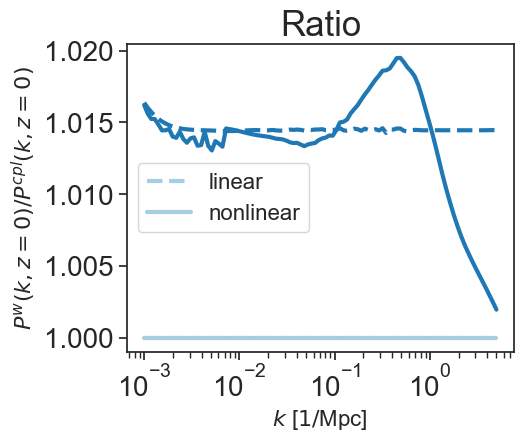

In [51]:
# Create the figure
plt.figure(figsize=(5, 4))

plt.semilogx(ks, ps_lin_cpl/ps_lin_cpl, label='linear', color='C0', linestyle='--' )
plt.semilogx(ks, ps_nonlin_cpl[0]/ps_nonlin_cpl[0], label='nonlinear', color='C0' )
plt.semilogx(ks, ps_lin_de[0]/ps_lin_cpl, color='C1' , linestyle='--')
plt.semilogx(ks, ps_nonlin_de[0]/ps_nonlin_cpl[0], color='C1' )

plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P^{w}(k, z=0)/P^{cpl}(k, z=0)$', fontsize = 16)

plt.legend(fontsize = 16)
plt.title("Ratio")

# Compute $C_\ell$ for 3x2pt

## Set-up: n(z) from TR1, covariance for DR1, no mixing matrices

In [52]:
data_path = 'TR1_data/'


In [53]:
# Get n(z)
z_nz_pos, nz_pos = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_GC_C2020_sel_pv.fits')
z_nz_she, nz_she = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_WL_C2020_sel_pv.fits')


# Normalize and resample n(z) for both position and shear
zs = np.linspace(1e-4, 3.0, 100)
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_pos, z_nz_pos)
dndz_she_norm = normalize_dndz(nz_she, z_nz_she)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz_pos, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz_she, zs)

In [54]:
print('z in fits: ', z_nz_pos.shape, z_nz_she.shape)
print('pos: ', z_nz_pos[0], z_nz_pos[-1])
print('she: ', z_nz_she[0], z_nz_she[-1])
print('zs interpolated: ', zs.shape, zs[0], zs[-1])

z in fits:  (3001,) (3001,)
pos:  0.0 6.0
she:  0.0 6.0
zs interpolated:  (100,) 0.0001 3.0


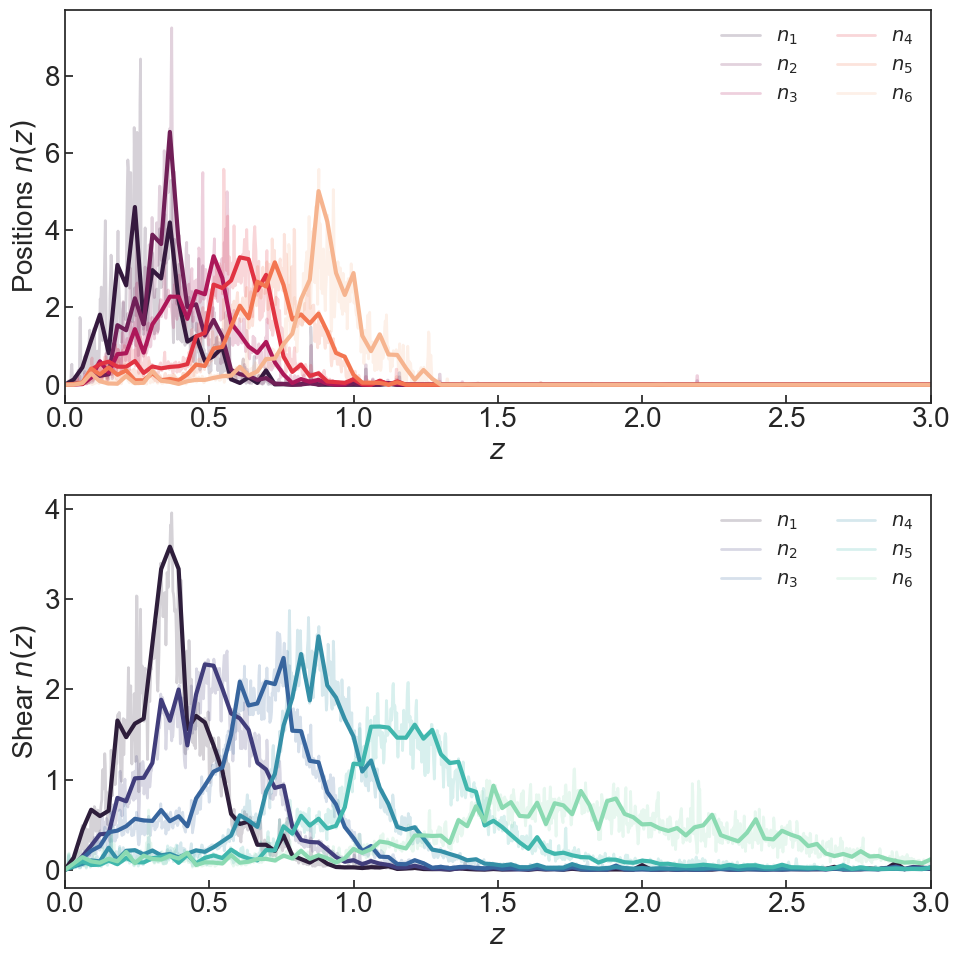

In [55]:
# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz_pos, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color, alpha=0.2)

for i in range(6):
    axs[0].plot(zs, my_dndz_pos_norm[i], color=sns.color_palette("rocket", len(dndz_pos_norm))[i])

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz_she, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color, alpha=0.2)

for i in range(6):
    axs[1].plot(zs, my_dndz_she_norm[i], color=sns.color_palette("mako", len(dndz_she_norm))[i])

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 3)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 3)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [56]:
cells_data = el.le3.pk_wl.angular_power_spectra(data_path+'uncoupled_cls_example.fits')
full_cov=np.load(data_path+'covariance_Gauss_Euclid_DR1_brighter_cut_1589_TR1_2D.npz')['Gauss']


In [57]:
print('data: ', cells_data['SHE', 'SHE', 1, 1].shape)
print('covariance: ', full_cov.shape)

data:  (2, 2, 32)
covariance:  (2496, 2496)


In [58]:
fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,

    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'width_pos_1': 1.0, 'width_pos_2': 1.0,
    'width_pos_3': 1.0, 'width_pos_4': 1.0,
    'width_pos_5': 1.0, 'width_pos_6': 1.0,

    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,

    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'width_shear_1': 1.0, 'width_shear_2': 1.0,
    'width_shear_3': 1.0, 'width_shear_4': 1.0,
    'width_shear_5': 1.0, 'width_shear_6': 1.0

}

#32 modes
ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

In [59]:
tracer_she = ShearTracer(perturbations=nonlinear_perturbations_lcdm, 
                            dndz=my_dndz_she_norm,
                            z = zs,
                            nuisance_params=fiducial_nuisance)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
cells_EE = twopoint_sheshe.get_Cl(ell_theory, 0, nonlinear_perturbations_lcdm.k)
cells_shear= cells_EE

In [60]:
tracer_she_cpl = ShearTracer(perturbations=nonlinear_perturbations_cpl, 
                            dndz=my_dndz_she_norm,
                            z = zs,
                            nuisance_params=fiducial_nuisance)
twopoint_sheshe_cpl = AngularTwoPoint(tracer_she_cpl, tracer_she_cpl)
start = time.time()
cells_EE_cpl = twopoint_sheshe_cpl.get_Cl(ell_theory, 0, nonlinear_perturbations_cpl.k)
finish = time.time()
print(finish-start)
cells_shear_cpl= cells_EE_cpl

0.014610052108764648


In [61]:
tracer_she_de = ShearTracer(perturbations=nonlinear_perturbations_de, 
                            dndz=my_dndz_she_norm,
                            z = zs,
                            nuisance_params=fiducial_nuisance)
twopoint_sheshe_de = AngularTwoPoint(tracer_she_de, tracer_she_de)
start = time.time()
cells_EE_de = twopoint_sheshe_de.get_Cl(ell_theory, 0, nonlinear_perturbations_de.k)
finish = time.time()
print(finish-start)
cells_shear_de= cells_EE_de

0.11473369598388672


In [62]:
cov_WL = full_cov[:(21+21)*32, :(21+21)*32]
diag_error = np.sqrt(np.diag(cov_WL))
diag_error.shape

(1344,)

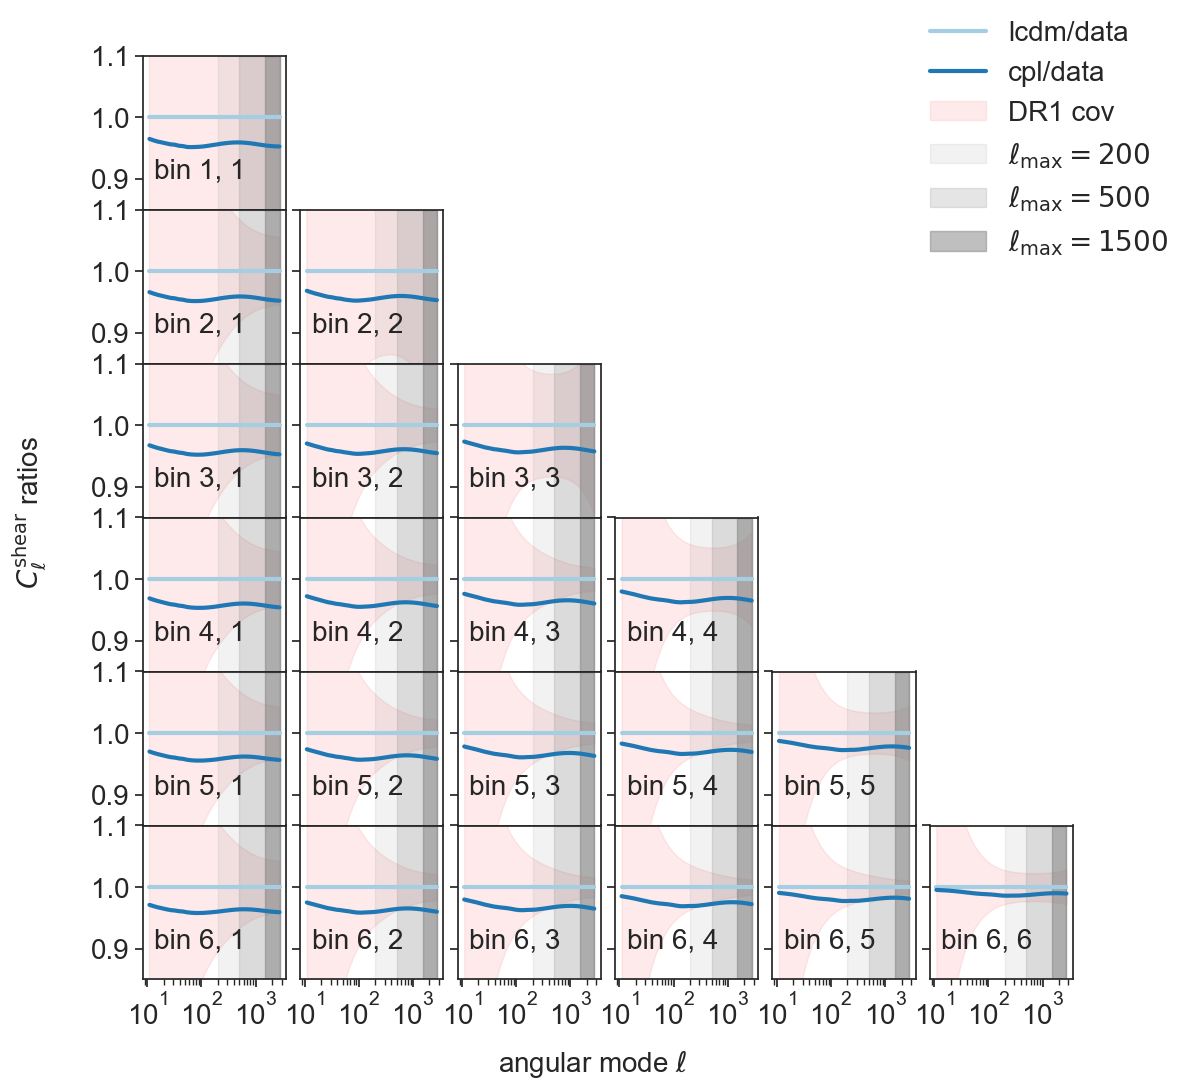

In [76]:
nbin = 6
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ratio = cells_shear['SHE', 'SHE', j+1, i+1][0][0]/cells_data['SHE', 'SHE', j+1, i+1][0][0]
            #err = np.sqrt(np.diag(cov_WL[j*32:(j+1)*32, i*32:(i+1)*32])),#*ratio/cells_data['SHE', 'SHE', j+1, i+1][0][0],
            ax[i, j].semilogx(ell_theory, ratio)
            ax[i, j].semilogx(ell_theory, cells_shear_cpl['SHE', 'SHE', j+1, i+1][0][0]/cells_data['SHE', 'SHE', j+1, i+1][0][0])
            ax[i, j].fill_between(ell_theory, 1.-np.sqrt(np.diag(cov_WL[j*32:(j+1)*32, i*32:(i+1)*32]))/cells_data['SHE', 'SHE', j+1, i+1][0][0], 1.+np.sqrt(np.diag(cov_WL[j*32:(j+1)*32, i*32:(i+1)*32]))/cells_data['SHE', 'SHE', j+1, i+1][0][0], alpha=0.2, color='C4')
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=200, xmax=ell_theory[-1], color='grey', alpha=0.1)
            ax[i, j].axvspan(xmin=500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            ax[i, j].axvspan(xmin=1500, xmax=ell_theory[-1], color='grey', alpha=0.5)
            ax[i,j].set_ylim(0.85, 1.1)
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm shear}_{\ell}$ ratios', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(['lcdm/data', 'cpl/data', 'DR1 cov', '$\\ell_{\\rm max}=200$', '$\\ell_{\\rm max}=500$', '$\\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

In [64]:
myz = zs

In [65]:
perturbations = nonlinear_perturbations_lcdm
# Tracer definitions (easy to swap dndz, bias model, etc.)
tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=fiducial_nuisance
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    nuisance_params=fiducial_nuisance
)

cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)

In [66]:
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}

In [67]:
def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    scale_cuts = {}

    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts[key] = [10, 750]

        elif key[:2] == ('POS', 'SHE'):
            scale_cuts[key] = [10, 750]

        elif key[:2] == ('SHE', 'SHE'):
            scale_cuts[key] = [10, 1500]

    return {
        'n_ell_bins': 32,
        'scale_cuts': scale_cuts
    }


In [68]:
data_3x2pt  = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

In [69]:
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt
like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"
    )

In [70]:
loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial: ", loglike)

✨ Log-likelihood at fiducial:  0.0


In [71]:
fiducial_cosmology['w0']=-0.9
loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at w0=-0.9: ", loglike)
fiducial_cosmology['w0']=-1.

✨ Log-likelihood at w0=-0.9:  -70.74962592777263


In [72]:
from cloelike.EuclidLikelihood_photo_Cls_de import EuclidLikelihood_3x2pt
like_instance_de = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=DEBackground,
        LinPerturbations=DELinearPerturbations,
        NonLinPerturbations=DENonlinearPerturbations,
        mode="uncoupled"
    )

In [73]:
fiducial_cosmology_de = fiducial_cosmology.copy()
fiducial_cosmology_de["zbin_edges"] = np.array(zbin_edges)
fiducial_cosmology_de["w_i"] = np.array(w_i_amp_cpl_centers)
fiducial_cosmology_de["binning"] = "step"

In [74]:
loglike_de = like_instance_de.loglike(fiducial_cosmology_de | fiducial_nuisance)
print("✨ Log-likelihood for step-function de: ", loglike_de)

✨ Log-likelihood for step-function de:  -28.595929498196877


In [75]:
start = time.time()
like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
finish = time.time()
print('standard time for 1 like: ', finish-start)
start = time.time()
like_instance_de.loglike(fiducial_cosmology_de | fiducial_nuisance)
finish = time.time()
print('de step time for 1 like: ', finish-start)

standard time for 1 like:  0.15715813636779785
de step time for 1 like:  0.3994419574737549
